# 21. 멀티모달 RAG 최종 프로젝트

## 최종 통합 프로젝트
지금까지 학습한 기술을 하나의 프로젝트로 통합한다.

```text
고해상도 Image Dataset
 → CLIP Embedding
 → Qdrant
 → Text-to-Image Retrieval
 → Metadata
 → Top-K Context
 → Qwen2.5-VL
 → Korean Grounded Answer
 → Evaluation
 → 결과 저장
```

이 Notebook은 수강생이 최종 프로젝트의 **구조, 함수 분리, 실행 순서, 산출물**을 한 번에 확인하도록 구성한다.

## 1. 최종 프로젝트 요구사항

- 고해상도 이미지 사용
- CLIP 기반 검색
- Qdrant Vector DB
- Top-K 검색
- Payload 활용
- Qwen2.5-VL 한국어 VQA
- 검색/생성 결과 저장
- Retrieval 평가
- 사람 평가
- 오류 분석
- 최종 보고서 작성

In [1]:
# ---------------------------------------------------------
# 실행 시간 측정을 위해 time을 불러온다.
# ---------------------------------------------------------
import time
# ---------------------------------------------------------
# 결과를 JSON으로 저장하기 위해 json을 불러온다.
# ---------------------------------------------------------
import json
# ---------------------------------------------------------
# 파일 경로를 안전하게 처리하기 위해 Path를 불러온다.
# ---------------------------------------------------------
from pathlib import Path
# ---------------------------------------------------------
# Tensor 연산과 모델 추론을 위해 PyTorch를 불러온다.
# ---------------------------------------------------------
import torch
# ---------------------------------------------------------
# Embedding 정규화를 위해 functional API를 불러온다.
# ---------------------------------------------------------
import torch.nn.functional as F
# ---------------------------------------------------------
# 결과 분석을 위해 pandas를 불러온다.
# ---------------------------------------------------------
import pandas as pd
# ---------------------------------------------------------
# 결과 시각화를 위해 matplotlib를 불러온다.
# ---------------------------------------------------------
import matplotlib.pyplot as plt
# ---------------------------------------------------------
# 고해상도 이미지 Dataset을 사용하기 위해 Caltech101을 불러온다.
# ---------------------------------------------------------
from torchvision.datasets import Caltech101
# ---------------------------------------------------------
# CLIP 모델과 Processor를 불러온다.
# ---------------------------------------------------------
from transformers import CLIPModel, CLIPProcessor
# ---------------------------------------------------------
# Qwen2.5-VL Processor를 불러온다.
# ---------------------------------------------------------
from transformers import AutoProcessor
# ---------------------------------------------------------
# Qwen2.5-VL 모델을 불러온다.
# ---------------------------------------------------------
from transformers import Qwen2_5_VLForConditionalGeneration
# ---------------------------------------------------------
# Qdrant Client를 불러온다.
# ---------------------------------------------------------
from qdrant_client import QdrantClient
# ---------------------------------------------------------
# Qdrant 자료구조를 불러온다.
# ---------------------------------------------------------
from qdrant_client import models

c:\sk-encoa\llm-workspace\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
# ---------------------------------------------------------
# CUDA 사용 가능 여부를 먼저 확인한다.
# ---------------------------------------------------------
if torch.cuda.is_available():
    # -----------------------------------------------------
    # NVIDIA GPU가 있으면 CUDA를 사용한다.
    # -----------------------------------------------------
    device = torch.device("cuda")
# ---------------------------------------------------------
# CUDA가 없으면 Apple MPS 사용 가능 여부를 확인한다.
# ---------------------------------------------------------
elif hasattr(torch.backends, "mps") and torch.backends.mps.is_available():
    # -----------------------------------------------------
    # Apple Silicon 환경이면 MPS를 사용한다.
    # -----------------------------------------------------
    device = torch.device("mps")
# ---------------------------------------------------------
# 가속 장치가 없으면 CPU를 사용한다.
# ---------------------------------------------------------
else:
    # -----------------------------------------------------
    # CPU Device를 선택한다.
    # -----------------------------------------------------
    device = torch.device("cpu")
# ---------------------------------------------------------
# 선택된 Device를 확인한다.
# ---------------------------------------------------------
print("Device:", device)

Device: cpu


## 2. 프로젝트 설정

In [3]:
# ---------------------------------------------------------
# CLIP 모델 이름을 지정한다.
# ---------------------------------------------------------
CLIP_MODEL_NAME = "openai/clip-vit-base-patch32"
# ---------------------------------------------------------
# Qwen 모델 이름을 지정한다.
# ---------------------------------------------------------
QWEN_MODEL_NAME = "Qwen/Qwen2.5-VL-3B-Instruct"
# ---------------------------------------------------------
# 프로젝트 Collection 이름을 지정한다.
# ---------------------------------------------------------
COLLECTION_NAME = "final_multimodal_project"
# ---------------------------------------------------------
# 수업 실행 시간을 고려하여 사용할 이미지 수를 지정한다.
# ---------------------------------------------------------
MAX_IMAGES = 500
# ---------------------------------------------------------
# 결과 저장 폴더를 지정한다.
# ---------------------------------------------------------
RESULT_DIR = Path("./final_multimodal_project")
# ---------------------------------------------------------
# 결과 폴더를 생성한다.
# ---------------------------------------------------------
RESULT_DIR.mkdir(parents=True, exist_ok=True)
# ---------------------------------------------------------
# Qdrant 저장 경로를 지정한다.
# ---------------------------------------------------------
QDRANT_PATH = RESULT_DIR / "qdrant_storage"
# ---------------------------------------------------------
# Dataset을 불러온다.
# ---------------------------------------------------------
dataset = Caltech101(root="./data", target_type="category", download=True)
# ---------------------------------------------------------
# 클래스 이름을 저장한다.
# ---------------------------------------------------------
class_names = dataset.categories
# ---------------------------------------------------------
# 실제 사용할 이미지 수를 계산한다.
# ---------------------------------------------------------
image_count = min(MAX_IMAGES, len(dataset))
# ---------------------------------------------------------
# 설정을 출력한다.
# ---------------------------------------------------------
print("Images:", image_count)

Images: 500


## 3. 원본 이미지 품질 검사

In [4]:
# ---------------------------------------------------------
# 품질 점검 결과를 저장할 List를 만든다.
# ---------------------------------------------------------
quality_rows = []
# ---------------------------------------------------------
# Sample 이미지 20개를 점검한다.
# ---------------------------------------------------------
for index in range(min(20, image_count)):
    # -----------------------------------------------------
    # 원본 PIL Image와 Label을 가져온다.
    # -----------------------------------------------------
    image, label = dataset[index]
    # -----------------------------------------------------
    # 원본 Width와 Height를 가져온다.
    # -----------------------------------------------------
    width, height = image.size
    # -----------------------------------------------------
    # 품질 정보를 저장한다.
    # -----------------------------------------------------
    quality_rows.append({"index":index,"class_name":class_names[label],"width":width,"height":height,"min_side":min(width,height)})
# ---------------------------------------------------------
# 품질 정보를 DataFrame으로 만든다.
# ---------------------------------------------------------
quality_df = pd.DataFrame(quality_rows)
# ---------------------------------------------------------
# 품질 정보를 출력한다.
# ---------------------------------------------------------
print(quality_df)

    index class_name  width  height  min_side
0       0      Faces    510     337       337
1       1      Faces    519     343       343
2       2      Faces    492     325       325
3       3      Faces    538     355       355
4       4      Faces    528     349       349
5       5      Faces    513     339       339
6       6      Faces    545     360       360
7       7      Faces    555     367       367
8       8      Faces    504     333       333
9       9      Faces    532     351       351
10     10      Faces    479     316       316
11     11      Faces    501     331       331
12     12      Faces    466     308       308
13     13      Faces    552     364       364
14     14      Faces    542     358       358
15     15      Faces    473     313       313
16     16      Faces    471     311       311
17     17      Faces    481     318       318
18     18      Faces    516     341       341
19     19      Faces    454     299       299


## 4. CLIP + Qdrant Knowledge Base 구축

In [5]:
# ---------------------------------------------------------
# CLIP Processor를 불러온다.
# ---------------------------------------------------------
clip_processor = CLIPProcessor.from_pretrained(CLIP_MODEL_NAME)
# ---------------------------------------------------------
# CLIP 모델을 불러온다.
# ---------------------------------------------------------
clip_model = CLIPModel.from_pretrained(CLIP_MODEL_NAME).to(device)
# ---------------------------------------------------------
# 추론 모드로 변경한다.
# ---------------------------------------------------------
clip_model.eval()
# ---------------------------------------------------------
# Qdrant Client를 생성한다.
# ---------------------------------------------------------
client = QdrantClient(path=str(QDRANT_PATH))
# ---------------------------------------------------------
# 기존 Collection 이름을 가져온다.
# ---------------------------------------------------------
names = [c.name for c in client.get_collections().collections]
# ---------------------------------------------------------
# 기존 프로젝트 Collection이 있으면 삭제한다.
# ---------------------------------------------------------
if COLLECTION_NAME in names:
    # -----------------------------------------------------
    # 동일한 조건으로 재현하기 위해 기존 Collection을 삭제한다.
    # -----------------------------------------------------
    client.delete_collection(collection_name=COLLECTION_NAME)
# ---------------------------------------------------------
# 첫 이미지로 Embedding 차원을 확인한다.
# ---------------------------------------------------------
sample_image, _ = dataset[0]
# ---------------------------------------------------------
# Sample Image를 Processor로 변환한다.
# ---------------------------------------------------------
sample_inputs = clip_processor(images=[sample_image], return_tensors="pt").to(device)
# ---------------------------------------------------------
# Sample Embedding을 생성한다.
# ---------------------------------------------------------
with torch.inference_mode():
    # -----------------------------------------------------
    # Image Feature를 계산한다.
    # -----------------------------------------------------
    # Vision Encoder의 출력 객체에서 pooled Tensor를 추출한다.
    sample_outputs = clip_model.vision_model(pixel_values=sample_inputs["pixel_values"])
    # 학습된 Projection Layer로 공유 임베딩 공간에 투영한다.
    sample_vector = clip_model.visual_projection(sample_outputs.pooler_output)
# ---------------------------------------------------------
# Embedding 차원을 구한다.
# ---------------------------------------------------------
dim = int(sample_vector.shape[1])
# ---------------------------------------------------------
# Cosine Distance Collection을 만든다.
# ---------------------------------------------------------
client.create_collection(collection_name=COLLECTION_NAME, vectors_config=models.VectorParams(size=dim, distance=models.Distance.COSINE))
# ---------------------------------------------------------
# 이미지를 Batch 단위로 처리한다.
# ---------------------------------------------------------
for start in range(0, image_count, 32):
    # -----------------------------------------------------
    # 현재 Batch 끝 위치를 계산한다.
    # -----------------------------------------------------
    end = min(start + 32, image_count)
    # -----------------------------------------------------
    # Batch Index를 만든다.
    # -----------------------------------------------------
    indices = list(range(start, end))
    # -----------------------------------------------------
    # 원본 이미지를 가져온다.
    # -----------------------------------------------------
    images = [dataset[i][0] for i in indices]
    # -----------------------------------------------------
    # 이미지를 CLIP 입력으로 변환한다.
    # -----------------------------------------------------
    inputs = clip_processor(images=images, return_tensors="pt").to(device)
    # -----------------------------------------------------
    # Image Embedding을 생성한다.
    # -----------------------------------------------------
    with torch.inference_mode():
        # -------------------------------------------------
        # CLIP Image Feature를 계산한다.
        # -------------------------------------------------
        # Vision Encoder의 출력 객체에서 pooled Tensor를 추출한다.
        image_outputs = clip_model.vision_model(pixel_values=inputs["pixel_values"])
        # CLIP 이미지 Projection Layer를 적용한다.
        vectors = clip_model.visual_projection(image_outputs.pooler_output)
    # -----------------------------------------------------
    # Embedding을 L2 정규화한다.
    # -----------------------------------------------------
    vectors = F.normalize(vectors, p=2, dim=-1)
    # -----------------------------------------------------
    # Qdrant Point List를 만든다.
    # -----------------------------------------------------
    points = []
    # -----------------------------------------------------
    # Batch의 각 이미지를 Point로 만든다.
    # -----------------------------------------------------
    for local, idx in enumerate(indices):
        # -------------------------------------------------
        # 이미지와 Label을 가져온다.
        # -------------------------------------------------
        image, label = dataset[idx]
        # -------------------------------------------------
        # 원본 해상도를 가져온다.
        # -------------------------------------------------
        width, height = image.size
        # -------------------------------------------------
        # Vector와 Payload를 Point로 구성한다.
        # -------------------------------------------------
        points.append(models.PointStruct(id=idx, vector=vectors[local].cpu().tolist(), payload={"dataset_index":idx,"class_name":class_names[label],"width":width,"height":height}))
    # -----------------------------------------------------
    # 현재 Batch를 Qdrant에 저장한다.
    # -----------------------------------------------------
    client.upsert(collection_name=COLLECTION_NAME, points=points, wait=True)
# ---------------------------------------------------------
# 구축된 Point 수를 출력한다.
# ---------------------------------------------------------
print("Points:", client.get_collection(COLLECTION_NAME).points_count)

Loading weights: 100%|██████████| 398/398 [00:00<00:00, 21611.73it/s]


Points: 500


## 5. 검색 함수

In [6]:
# ---------------------------------------------------------
# 자연어로 이미지를 검색하는 함수를 정의한다.
# ---------------------------------------------------------
def search_images(query, top_k=5):
    # -----------------------------------------------------
    # 검색어를 CLIP 입력으로 변환한다.
    # -----------------------------------------------------
    inputs = clip_processor(text=[query], return_tensors="pt", padding=True).to(device)
    # -----------------------------------------------------
    # Text Embedding을 생성한다.
    # -----------------------------------------------------
    with torch.inference_mode():
        # -------------------------------------------------
        # CLIP Text Feature를 계산한다.
        # -------------------------------------------------
        # Text Encoder의 출력 객체에서 pooled Tensor를 추출한다.
        text_outputs = clip_model.text_model(input_ids=inputs["input_ids"], attention_mask=inputs.get("attention_mask"))
        # CLIP 텍스트 Projection Layer를 적용한다.
        vector = clip_model.text_projection(text_outputs.pooler_output)
    # -----------------------------------------------------
    # Vector를 정규화한다.
    # -----------------------------------------------------
    vector = F.normalize(vector, p=2, dim=-1)
    # -----------------------------------------------------
    # 검색 시작 시간을 기록한다.
    # -----------------------------------------------------
    start = time.perf_counter()
    # -----------------------------------------------------
    # Qdrant Semantic Search를 수행한다.
    # -----------------------------------------------------
    response = client.query_points(collection_name=COLLECTION_NAME, query=vector[0].cpu().tolist(), limit=top_k, with_payload=True)
    # -----------------------------------------------------
    # 검색 시간을 계산한다.
    # -----------------------------------------------------
    latency_ms = (time.perf_counter() - start) * 1000
    # -----------------------------------------------------
    # 검색 결과와 시간을 반환한다.
    # -----------------------------------------------------
    return response.points, latency_ms
# ---------------------------------------------------------
# 예제 검색을 수행한다.
# ---------------------------------------------------------
results, latency = search_images("a photo of an airplane", top_k=5)
# ---------------------------------------------------------
# 결과를 출력한다.
# ---------------------------------------------------------
print([(p.payload["class_name"], round(p.score, 4)) for p in results])
print("Latency(ms):", latency)

[('Faces_easy', 0.2183), ('Faces', 0.2083), ('Faces', 0.2067), ('Faces', 0.2049), ('Faces_easy', 0.204)]
Latency(ms): 6.694499999866821


## 6. 검색 결과 시각화

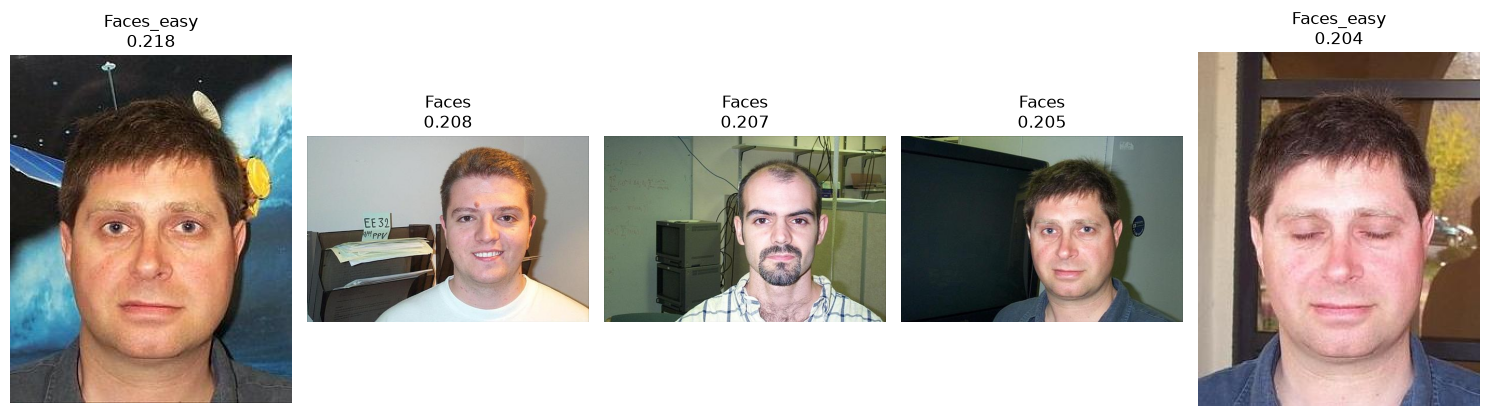

In [7]:
# ---------------------------------------------------------
# 검색 결과 개수에 맞는 Figure를 만든다.
# ---------------------------------------------------------
plt.figure(figsize=(15, 4))
# ---------------------------------------------------------
# 검색 결과를 순회한다.
# ---------------------------------------------------------
for pos, point in enumerate(results, start=1):
    # -----------------------------------------------------
    # Payload Index로 원본 이미지를 가져온다.
    # -----------------------------------------------------
    image, _ = dataset[point.payload["dataset_index"]]
    # -----------------------------------------------------
    # Subplot 위치를 지정한다.
    # -----------------------------------------------------
    plt.subplot(1, len(results), pos)
    # -----------------------------------------------------
    # 원본 이미지를 표시한다.
    # -----------------------------------------------------
    plt.imshow(image)
    # -----------------------------------------------------
    # 클래스와 Score를 제목으로 표시한다.
    # -----------------------------------------------------
    plt.title(f'{point.payload["class_name"]}\n{point.score:.3f}')
    # -----------------------------------------------------
    # 축을 제거한다.
    # -----------------------------------------------------
    plt.axis("off")
# ---------------------------------------------------------
# Layout을 정리한다.
# ---------------------------------------------------------
plt.tight_layout()
# ---------------------------------------------------------
# 결과를 표시한다.
# ---------------------------------------------------------
plt.show()

## 7. Retrieval 평가

In [8]:
# ---------------------------------------------------------
# 현재 Knowledge Base에 존재하는 클래스별 수를 계산한다.
# ---------------------------------------------------------
counts = {}
# ---------------------------------------------------------
# 등록된 이미지들을 순회한다.
# ---------------------------------------------------------
for i in range(image_count):
    # -----------------------------------------------------
    # 현재 Label을 가져온다.
    # -----------------------------------------------------
    _, label = dataset[i]
    # -----------------------------------------------------
    # 클래스 이름을 가져온다.
    # -----------------------------------------------------
    name = class_names[label]
    # -----------------------------------------------------
    # 클래스별 개수를 증가시킨다.
    # -----------------------------------------------------
    counts[name] = counts.get(name, 0) + 1
# ---------------------------------------------------------
# 최대 10개 클래스를 평가 대상으로 선택한다.
# ---------------------------------------------------------
eval_classes = sorted(counts)[:10]
# ---------------------------------------------------------
# 평가 결과를 저장할 List를 만든다.
# ---------------------------------------------------------
evaluation = []
# ---------------------------------------------------------
# 각 클래스를 평가한다.
# ---------------------------------------------------------
for name in eval_classes:
    # -----------------------------------------------------
    # 자연어 Query를 만든다.
    # -----------------------------------------------------
    query = f"a photo of a {name.replace('_', ' ')}"
    # -----------------------------------------------------
    # Top-5 검색을 수행한다.
    # -----------------------------------------------------
    points, latency_ms = search_images(query, 5)
    # -----------------------------------------------------
    # Top-5 정답 개수를 계산한다.
    # -----------------------------------------------------
    correct = sum(p.payload["class_name"] == name for p in points)
    # -----------------------------------------------------
    # Precision@5를 계산한다.
    # -----------------------------------------------------
    precision = correct / max(len(points), 1)
    # -----------------------------------------------------
    # Hit@5를 계산한다.
    # -----------------------------------------------------
    hit = 1 if correct > 0 else 0
    # -----------------------------------------------------
    # 결과를 저장한다.
    # -----------------------------------------------------
    evaluation.append({"class_name":name,"precision_at_5":precision,"hit_at_5":hit,"latency_ms":latency_ms})
# ---------------------------------------------------------
# 평가 결과를 DataFrame으로 만든다.
# ---------------------------------------------------------
evaluation_df = pd.DataFrame(evaluation)
# ---------------------------------------------------------
# 평가 결과를 출력한다.
# ---------------------------------------------------------
print(evaluation_df)

   class_name  precision_at_5  hit_at_5  latency_ms
0       Faces             1.0         1      3.5065
1  Faces_easy             0.0         0      3.7668


## 8. Qwen2.5-VL 연결

GPU 메모리가 작은 환경에서는 CLIP 검색을 끝낸 뒤 CLIP을 해제하고 Qwen을 로드하는 것이 안전하다.

In [9]:
# ---------------------------------------------------------
# Qwen에 전달할 Top-3 결과를 미리 저장한다.
# ---------------------------------------------------------
rag_points = results[:3]
# ---------------------------------------------------------
# 원본 PIL Image를 미리 가져온다.
# ---------------------------------------------------------
rag_images = [dataset[p.payload["dataset_index"]][0] for p in rag_points]
# ---------------------------------------------------------
# CLIP 모델을 삭제한다.
# ---------------------------------------------------------
del clip_model
# ---------------------------------------------------------
# CUDA 환경이면 Cache를 정리한다.
# ---------------------------------------------------------
if device.type == "cuda":
    torch.cuda.empty_cache()
# ---------------------------------------------------------
# CUDA에서는 bfloat16을 사용한다.
# ---------------------------------------------------------
qwen_dtype = torch.bfloat16 if device.type == "cuda" else torch.float32
# ---------------------------------------------------------
# Qwen Processor를 불러온다.
# ---------------------------------------------------------
qwen_processor = AutoProcessor.from_pretrained(QWEN_MODEL_NAME)
# ---------------------------------------------------------
# Qwen 모델을 불러온다.
# ---------------------------------------------------------
qwen_model = Qwen2_5_VLForConditionalGeneration.from_pretrained(QWEN_MODEL_NAME, torch_dtype=qwen_dtype).to(device)
# ---------------------------------------------------------
# Qwen 모델을 추론 모드로 변경한다.
# ---------------------------------------------------------
qwen_model.eval()

Loading weights: 100%|██████████| 824/824 [00:37<00:00, 21.80it/s]


Qwen2_5_VLForConditionalGeneration(
  (model): Qwen2_5_VLModel(
    (visual): Qwen2_5_VisionTransformerPretrainedModel(
      (patch_embed): Qwen2_5_VisionPatchEmbed(
        (proj): Conv3d(3, 1280, kernel_size=(2, 14, 14), stride=(2, 14, 14), bias=False)
      )
      (rotary_pos_emb): Qwen2_5_VLVisionRotaryEmbedding()
      (blocks): ModuleList(
        (0-31): 32 x Qwen2_5_VLVisionBlock(
          (norm1): Qwen2_5_VLRMSNorm((1280,), eps=1e-06)
          (norm2): Qwen2_5_VLRMSNorm((1280,), eps=1e-06)
          (attn): Qwen2_5_VLVisionAttention(
            (qkv): Linear(in_features=1280, out_features=3840, bias=True)
            (proj): Linear(in_features=1280, out_features=1280, bias=True)
          )
          (mlp): Qwen2_5_VLMLP(
            (gate_proj): Linear(in_features=1280, out_features=3420, bias=True)
            (up_proj): Linear(in_features=1280, out_features=3420, bias=True)
            (down_proj): Linear(in_features=3420, out_features=1280, bias=True)
            (act

## 9. Grounded Answer 함수

In [10]:
# ---------------------------------------------------------
# 검색 이미지를 근거로 한국어 답변을 생성하는 함수를 정의한다.
# ---------------------------------------------------------
def grounded_answer(images, points, question):
    # -----------------------------------------------------
    # Multimodal Content List를 만든다.
    # -----------------------------------------------------
    content = []
    # -----------------------------------------------------
    # 검색 이미지를 Content에 추가한다.
    # -----------------------------------------------------
    for image in images:
        # -------------------------------------------------
        # 현재 PIL Image를 추가한다.
        # -------------------------------------------------
        content.append({"type":"image","image":image})
    # -----------------------------------------------------
    # 검색 Metadata를 문자열로 만든다.
    # -----------------------------------------------------
    metadata = "\n".join(f'{i+1}. class={p.payload["class_name"]}, score={p.score:.4f}' for i,p in enumerate(points))
    # -----------------------------------------------------
    # 근거 제한 Prompt를 만든다.
    # -----------------------------------------------------
    prompt = f"검색 메타데이터:\n{metadata}\n\n제공된 이미지에서 확인되는 내용만 근거로 한국어로 답하세요. 확인할 수 없는 내용은 추측하지 마세요.\n질문: {question}"
    # -----------------------------------------------------
    # Prompt를 Content에 추가한다.
    # -----------------------------------------------------
    content.append({"type":"text","text":prompt})
    # -----------------------------------------------------
    # Chat Message를 만든다.
    # -----------------------------------------------------
    messages = [{"role":"user","content":content}]
    # -----------------------------------------------------
    # Multimodal 입력 Tensor를 만든다.
    # -----------------------------------------------------
    inputs = qwen_processor.apply_chat_template(messages, tokenize=True, add_generation_prompt=True, return_dict=True, return_tensors="pt").to(device)
    # -----------------------------------------------------
    # Prompt Token 길이를 저장한다.
    # -----------------------------------------------------
    input_length = inputs["input_ids"].shape[1]
    # -----------------------------------------------------
    # 생성 시작 시간을 기록한다.
    # -----------------------------------------------------
    start = time.perf_counter()
    # -----------------------------------------------------
    # 답변을 생성한다.
    # -----------------------------------------------------
    with torch.inference_mode():
        # -------------------------------------------------
        # 최대 180개 새 Token을 생성한다.
        # -------------------------------------------------
        output = qwen_model.generate(**inputs, max_new_tokens=180, do_sample=False)
    # -----------------------------------------------------
    # CUDA 연산 완료를 기다린다.
    # -----------------------------------------------------
    if device.type == "cuda":
        torch.cuda.synchronize()
    # -----------------------------------------------------
    # 생성 시간을 계산한다.
    # -----------------------------------------------------
    latency = time.perf_counter() - start
    # -----------------------------------------------------
    # 새로 생성된 Token만 분리한다.
    # -----------------------------------------------------
    response_ids = output[:, input_length:]
    # -----------------------------------------------------
    # Token을 문자열로 변환한다.
    # -----------------------------------------------------
    answer = qwen_processor.batch_decode(response_ids, skip_special_tokens=True, clean_up_tokenization_spaces=False)[0]
    # -----------------------------------------------------
    # 답변과 시간을 반환한다.
    # -----------------------------------------------------
    return answer, latency
# ---------------------------------------------------------
# 최종 프로젝트 질문을 정의한다.
# ---------------------------------------------------------
question = "검색된 이미지의 주요 객체와 공통점을 설명해줘."
# ---------------------------------------------------------
# Grounded Answer를 생성한다.
# ---------------------------------------------------------
answer, generation_latency = grounded_answer(rag_images, rag_points, question)
# ---------------------------------------------------------
# 결과를 출력한다.
# ---------------------------------------------------------
print(answer)
print("Generation latency(sec):", generation_latency)

이미지의 주요 객체는 두 명의 남성입니다. 이들은 모두 머리에 꽃을 꽂고 있으며, 한 명은 흰색 티셔츠를 입고 있고 다른 한 명은 청자켓을 입고 있습니다. 공통점으로는 두 사람 모두 카메라를 바라보며 포즈를 취하고 있다는 점이 있습니다.
Generation latency(sec): 607.6127302999994


## 10. 프로젝트 결과 저장

In [11]:
# ---------------------------------------------------------
# Retrieval 평가 결과를 CSV로 저장한다.
# ---------------------------------------------------------
evaluation_df.to_csv(RESULT_DIR / "retrieval_evaluation.csv", index=False, encoding="utf-8-sig")
# ---------------------------------------------------------
# 최종 결과 Dictionary를 만든다.
# ---------------------------------------------------------
final_result = {
    "query": "a photo of an airplane",
    "retrieved_classes": [p.payload["class_name"] for p in rag_points],
    "scores": [float(p.score) for p in rag_points],
    "question": question,
    "answer": answer,
    "retrieval_latency_ms": float(latency),
    "generation_latency_sec": float(generation_latency),
    "human_evaluation": {
        "relevance_0_2": None,
        "groundedness_0_2": None,
        "hallucination_0_2": None
    }
}
# ---------------------------------------------------------
# 최종 결과를 JSON으로 저장한다.
# ---------------------------------------------------------
(RESULT_DIR / "final_result.json").write_text(json.dumps(final_result, ensure_ascii=False, indent=2), encoding="utf-8")
# ---------------------------------------------------------
# 저장 결과를 출력한다.
# ---------------------------------------------------------
print("Saved:", RESULT_DIR.resolve())

Saved: C:\sk-encoa\llm-workspace\멀티모달_CLIP_BLIP\final_multimodal_project


## 11. 최종 프로젝트 발표 구조

```text
1. 문제 정의
2. 데이터 설명
3. 이미지 품질 검증
4. CLIP 구조
5. Image Embedding
6. Qdrant Vector DB
7. Semantic Search
8. Top-K 결과
9. Qwen2.5-VL
10. Grounded Answer
11. Retrieval 평가
12. Generation 사람 평가
13. 오류 사례
14. 개선 방법
15. 결론
```

## 최종 산출물
- Notebook
- 실행 소스
- Qdrant DB
- Retrieval 평가 CSV
- 최종 결과 JSON
- 오류 분석표
- 프로젝트 보고서
- 발표자료

## 확인문제
1. Vector DB에는 무엇이 저장되는가?
2. Payload는 왜 필요한가?
3. 원본 이미지를 별도로 유지하는 이유는 무엇인가?
4. CLIP과 Qwen2.5-VL의 역할은 각각 무엇인가?
5. Retrieval과 Generation을 따로 평가하는 이유는 무엇인가?
6. Grounded Answer란 무엇인가?

## 정답
1. Image Embedding Vector와 Payload가 저장된다.
2. 클래스, Dataset Index, 해상도 등 구조화된 정보를 검색 결과와 연결하기 위해서이다.
3. VLM이 실제 시각 정보를 분석할 때 원본 품질이 필요하기 때문이다.
4. CLIP은 검색, Qwen2.5-VL은 검색 이미지 기반 이해와 답변 생성을 담당한다.
5. 오류 발생 위치를 정확히 파악하기 위해서이다.
6. 제공된 검색 근거를 중심으로 생성한 답변이다.